In [120]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aaryanbarthwal/airisfirstproject/sample_claims.csv


In [121]:
df = pd.read_csv("/kaggle/input/datasets/aaryanbarthwal/airisfirstproject/sample_claims.csv")
df['Total Paid'] =   df["Total Paid"].str.replace("$","")
df['Total Paid'] =   df["Total Paid"].str.replace(",","")
df["Total Paid"] = pd.to_numeric(df["Total Paid"])

df["Gender"] = df["Gender"].str.strip().str.lower()
df["Settled"] = df["Settled"].str.strip().str.lower()

df["Gender"] = df["Gender"].map({"male": 1, "female": 0})
df["Settled"] = df["Settled"].map({"y": 1, "n": 0})

target = "Days to RTW"
df

,Claim No,Occurrence No,Claim Financial Year,Agency NN,Incident Date,Finalised Date,Total Paid,Paid Days Lost,Injury Agency Group,Bodily Location Group,Mechanism Group,Nature Group,Occupation,Gender,Date of Birth,Days to RTW,RTW Category,Age at Accident Date,Settled
0,13/005096,1,2013,7069,01/11/2012,24/01/2013,8580.00,26.01,Mobile Plant and Transport,Trunk (inc. Back),Body Stressing,"Sprains, Strains and Dislocations",Personal Care Assistant,1.0,05/11/1956,46,RTW 13 Weeks,55,0
1,21/013033,1,2021,63246,29/04/2021,10/06/2021,573.66,2,"Non-powered Handtools, Appliances and Equipment",Head,"Falls, Slips and Trips of a Person",Open Wound,Teachers Aide (Education Assistant),0.0,18/08/1971,1,RTW 13 Weeks,49,0
2,16/005676,1,2016,2043954,16/11/2015,04/01/2016,796.97,2.02,"Animal, Human and Biological Agencies",Head,Being Hit by Moving Objects,Open Wound,Residential Care Officer,1.0,07/07/1967,1,RTW 13 Weeks,48,0
3,15/002879,1,2015,63246,04/09/2014,18/02/2015,5570.19,26,"Animal, Human and Biological Agencies",Lower Limbs,Body Stressing,"Sprains, Strains and Dislocations",Teachers Aide (Education Assistant),1.0,29/07/1973,35,RTW 13 Weeks,41,0
4,14/020489,2,2014,63246,08/05/2014,29/01/2016,35406.63,75.09,Environmental Agencies,Upper Limbs,"Falls, Slips and Trips of a Person","Sprains, Strains and Dislocations",General Gardener,1.0,06/02/1951,101,RTW 26 Weeks,63,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23134,22/016242,1,2022,63246,22/03/2022,26/06/2022,1470.12,6,"Animal, Human and Biological Agencies",Trunk (inc. Back),Body Stressing,"Sprains, Strains and Dislocations",Teachers Aide (Education Assistant),0.0,20/11/1972,7,RTW 13 Weeks,49,0
23135,16/001970,1,2016,63246,06/08/2015,09/11/2015,4730.55,5,"Animal, Human and Biological Agencies",Trunk (inc. Back),Body Stressing,"Sprains, Strains and Dislocations",Secondary School Teacher,0.0,16/04/1961,6,RTW 13 Weeks,54,0
23136,19/002320,1,2019,2623845,27/07/2018,14/09/2018,943.10,2,"Animal, Human and Biological Agencies",Trunk (inc. Back),Being Hit by Moving Objects,Mental Disorders,Registered Nurse,0.0,20/06/1969,3,RTW 13 Weeks,49,0
23137,13/014043,1,2013,2253554,21/03/2013,28/02/2014,2062.57,3,"Non-powered Handtools, Appliances and Equipment",Lower Limbs,"Falls, Slips and Trips of a Person","Sprains, Strains and Dislocations",Nursing Assistant,0.0,23/04/1955,2,RTW 13 Weeks,57,0


In [122]:
id_cols = [
    'Claim No',
    "Claim Number",
    "Claim ID",
    "Occurrence Number",
    "Customer ID"
]

leakage_cols = [
    "Finalized Date",
    "Closed Date",
    "Claim Status"
]

text_cols = [
    "Description",
    "Injury Notes"
]

cols_to_drop = id_cols + leakage_cols + text_cols

df = df.drop(columns=cols_to_drop, errors="ignore")
df

,Occurrence No,Claim Financial Year,Agency NN,Incident Date,Finalised Date,Total Paid,Paid Days Lost,Injury Agency Group,Bodily Location Group,Mechanism Group,Nature Group,Occupation,Gender,Date of Birth,Days to RTW,RTW Category,Age at Accident Date,Settled
0,1,2013,7069,01/11/2012,24/01/2013,8580.00,26.01,Mobile Plant and Transport,Trunk (inc. Back),Body Stressing,"Sprains, Strains and Dislocations",Personal Care Assistant,1.0,05/11/1956,46,RTW 13 Weeks,55,0
1,1,2021,63246,29/04/2021,10/06/2021,573.66,2,"Non-powered Handtools, Appliances and Equipment",Head,"Falls, Slips and Trips of a Person",Open Wound,Teachers Aide (Education Assistant),0.0,18/08/1971,1,RTW 13 Weeks,49,0
2,1,2016,2043954,16/11/2015,04/01/2016,796.97,2.02,"Animal, Human and Biological Agencies",Head,Being Hit by Moving Objects,Open Wound,Residential Care Officer,1.0,07/07/1967,1,RTW 13 Weeks,48,0
3,1,2015,63246,04/09/2014,18/02/2015,5570.19,26,"Animal, Human and Biological Agencies",Lower Limbs,Body Stressing,"Sprains, Strains and Dislocations",Teachers Aide (Education Assistant),1.0,29/07/1973,35,RTW 13 Weeks,41,0
4,2,2014,63246,08/05/2014,29/01/2016,35406.63,75.09,Environmental Agencies,Upper Limbs,"Falls, Slips and Trips of a Person","Sprains, Strains and Dislocations",General Gardener,1.0,06/02/1951,101,RTW 26 Weeks,63,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23134,1,2022,63246,22/03/2022,26/06/2022,1470.12,6,"Animal, Human and Biological Agencies",Trunk (inc. Back),Body Stressing,"Sprains, Strains and Dislocations",Teachers Aide (Education Assistant),0.0,20/11/1972,7,RTW 13 Weeks,49,0
23135,1,2016,63246,06/08/2015,09/11/2015,4730.55,5,"Animal, Human and Biological Agencies",Trunk (inc. Back),Body Stressing,"Sprains, Strains and Dislocations",Secondary School Teacher,0.0,16/04/1961,6,RTW 13 Weeks,54,0
23136,1,2019,2623845,27/07/2018,14/09/2018,943.10,2,"Animal, Human and Biological Agencies",Trunk (inc. Back),Being Hit by Moving Objects,Mental Disorders,Registered Nurse,0.0,20/06/1969,3,RTW 13 Weeks,49,0
23137,1,2013,2253554,21/03/2013,28/02/2014,2062.57,3,"Non-powered Handtools, Appliances and Equipment",Lower Limbs,"Falls, Slips and Trips of a Person","Sprains, Strains and Dislocations",Nursing Assistant,0.0,23/04/1955,2,RTW 13 Weeks,57,0


In [123]:
df = pd.get_dummies(df, columns=[
    'Injury Agency Group',
    'Bodily Location Group',
    'Mechanism Group',
    'Nature Group',
    'Occupation'
], drop_first=True)

In [124]:

# BASIC INFO

print(df.shape)
print(df.columns)
df.info()

(23139, 493)
Index(['Occurrence No', 'Claim Financial Year', 'Agency NN', 'Incident Date',
       'Finalised Date', 'Total Paid', 'Paid Days Lost', 'Gender',
       'Date of Birth', 'Days to RTW',
       ...
       'Occupation_Veterinary Nurse',
       'Occupation_Vocational Education Teacher', 'Occupation_Water Inspector',
       'Occupation_Water and Waste Water Plant Operator',
       'Occupation_Waterside Worker', 'Occupation_Welder (First Class)',
       'Occupation_Welfare Centre Manager', 'Occupation_Welfare Worker',
       'Occupation_Youth Worker', 'Occupation_Zoologist'],
      dtype='object', length=493)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23139 entries, 0 to 23138
Columns: 493 entries, Occurrence No to Occupation_Zoologist
dtypes: bool(480), float64(2), int64(6), object(5)
memory usage: 12.9+ MB


In [125]:
# DATA CLEANING

# Convert dates
df["Incident Date"] = pd.to_datetime(df["Incident Date"], dayfirst=True, errors="coerce")
df["Finalised Date"] = pd.to_datetime(df["Finalised Date"], dayfirst=True, errors="coerce")
df["Date of Birth"] = pd.to_datetime(df["Date of Birth"], dayfirst=True, errors="coerce")

# Convert numeric columns
df["Total Paid"] = pd.to_numeric(df["Total Paid"].astype(str).str.replace(r"[^\d.-]", "", regex=True), errors="coerce")
df["Paid Days Lost"] = pd.to_numeric(df["Paid Days Lost"], errors="coerce")

In [126]:

# CELL 5: FEATURE ENGINEERING


df["Claim Duration"] = (df["Finalised Date"] - df["Incident Date"]).dt.days

# recalculate age
df["Age Calculated"] = (df["Incident Date"] - df["Date of Birth"]).dt.days // 365


df.head()

,Occurrence No,Claim Financial Year,Agency NN,Incident Date,Finalised Date,Total Paid,Paid Days Lost,Gender,Date of Birth,Days to RTW,...,Occupation_Water Inspector,Occupation_Water and Waste Water Plant Operator,Occupation_Waterside Worker,Occupation_Welder (First Class),Occupation_Welfare Centre Manager,Occupation_Welfare Worker,Occupation_Youth Worker,Occupation_Zoologist,Claim Duration,Age Calculated
0,1,2013,7069,2012-11-01,2013-01-24,8580.00,26.01,1.0,1956-11-05,46,...,False,False,False,False,False,False,False,False,84,56.0
1,1,2021,63246,2021-04-29,2021-06-10,573.66,2.00,0.0,1971-08-18,1,...,False,False,False,False,False,False,False,False,42,49.0
2,1,2016,2043954,2015-11-16,2016-01-04,796.97,2.02,1.0,1967-07-07,1,...,False,False,False,False,False,False,False,False,49,48.0
3,1,2015,63246,2014-09-04,2015-02-18,5570.19,26.00,1.0,1973-07-29,35,...,False,False,False,False,False,False,False,False,167,41.0
4,2,2014,63246,2014-05-08,2016-01-29,35406.63,75.09,1.0,1951-02-06,101,...,False,False,False,False,False,False,False,False,631,63.0


In [127]:
# MISSING VALUES

print(df.isnull().sum())

# Fill missing values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")


Occurrence No                0
Claim Financial Year         0
Agency NN                    0
Incident Date                0
Finalised Date               0
                            ..
Occupation_Welfare Worker    0
Occupation_Youth Worker      0
Occupation_Zoologist         0
Claim Duration               0
Age Calculated               1
Length: 495, dtype: int64


In [128]:

# OUTLIER REMOVAL (SAFE VERSION)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

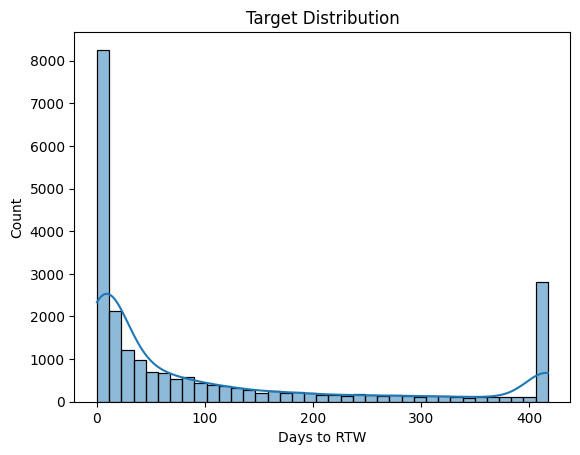

In [129]:
# =========================
# CELL 9: TARGET DISTRIBUTION
# =========================
plt.figure()
sns.histplot(df[target], kde=True)
plt.title("Target Distribution")
plt.show()

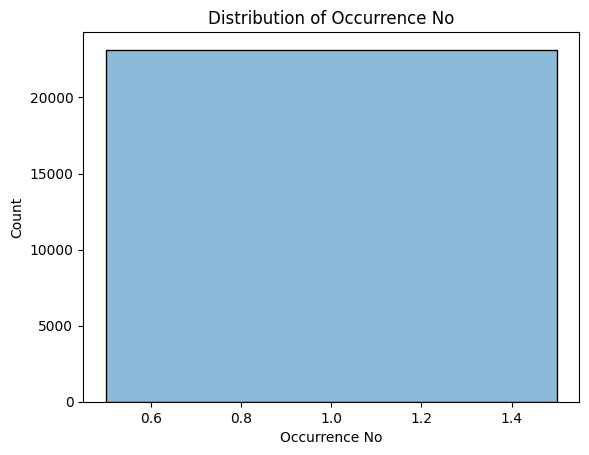

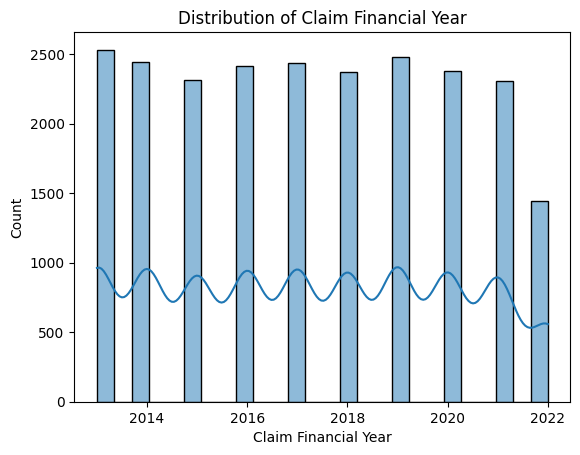

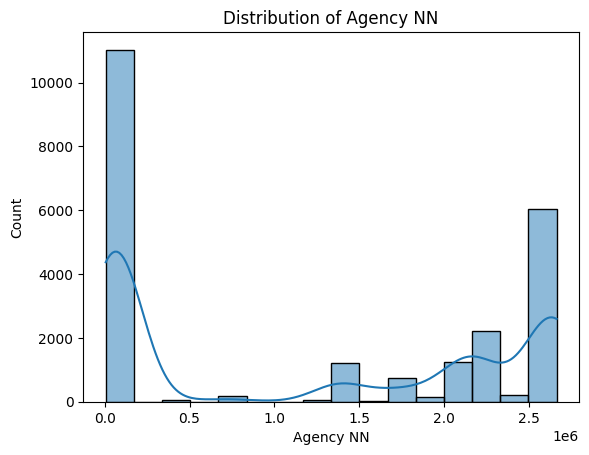

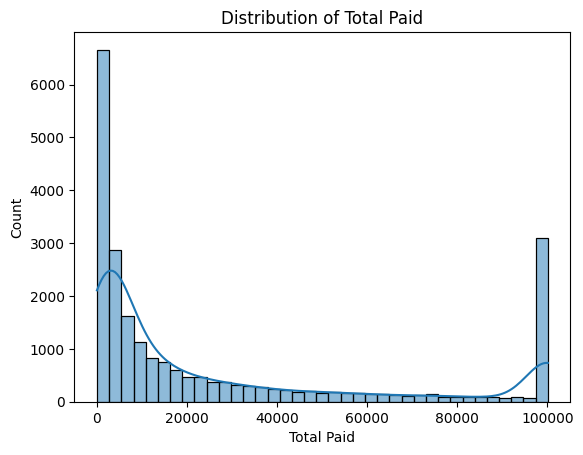

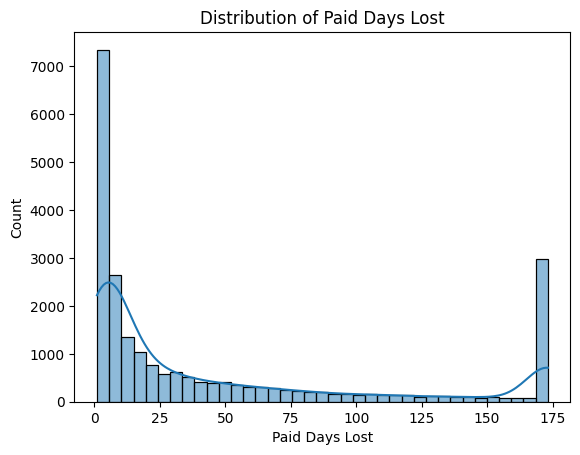

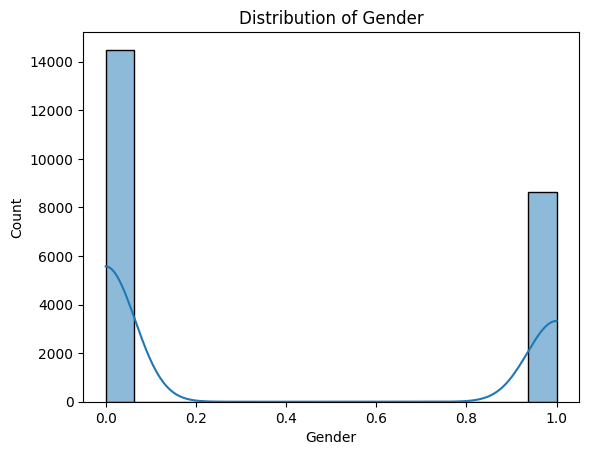

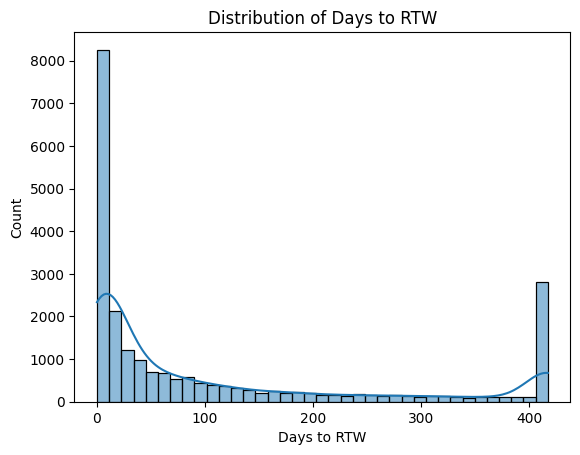

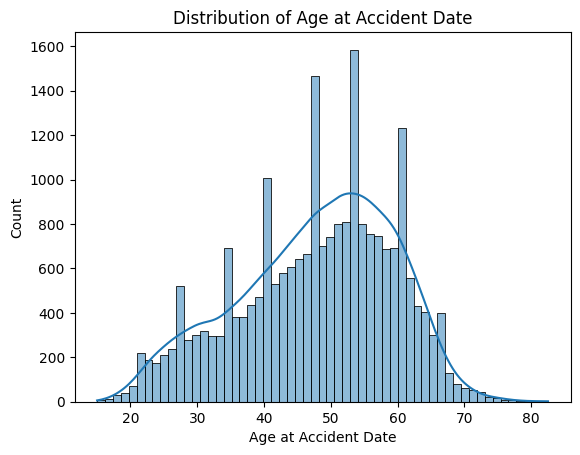

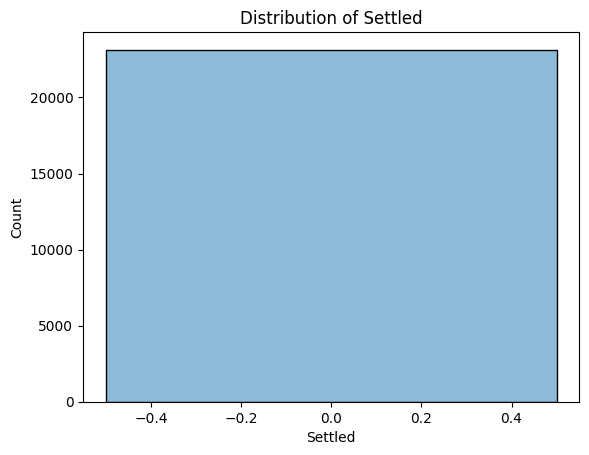

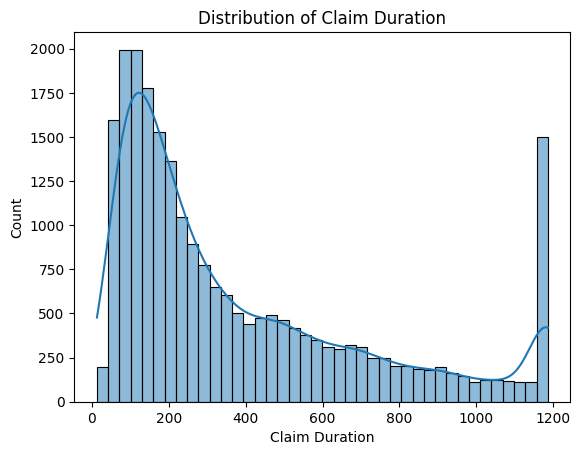

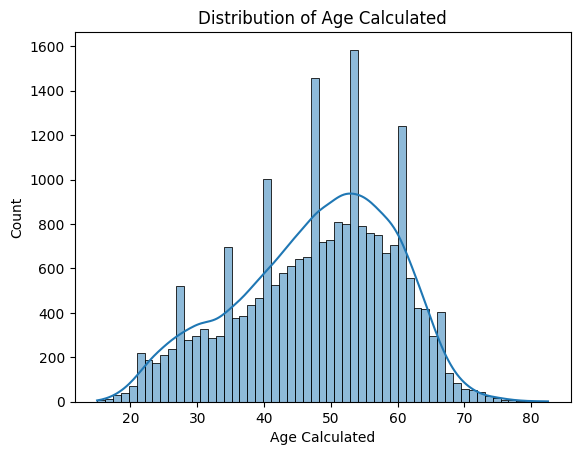

In [130]:

# NUMERICAL DISTRIBUTION

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

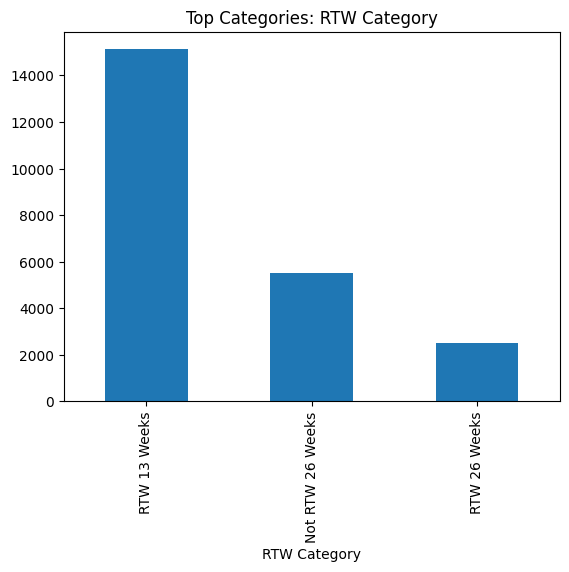

In [131]:

# CATEGORICAL ANALYSIS

for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top Categories: {col}")
    plt.xticks(rotation=90)
    plt.show()

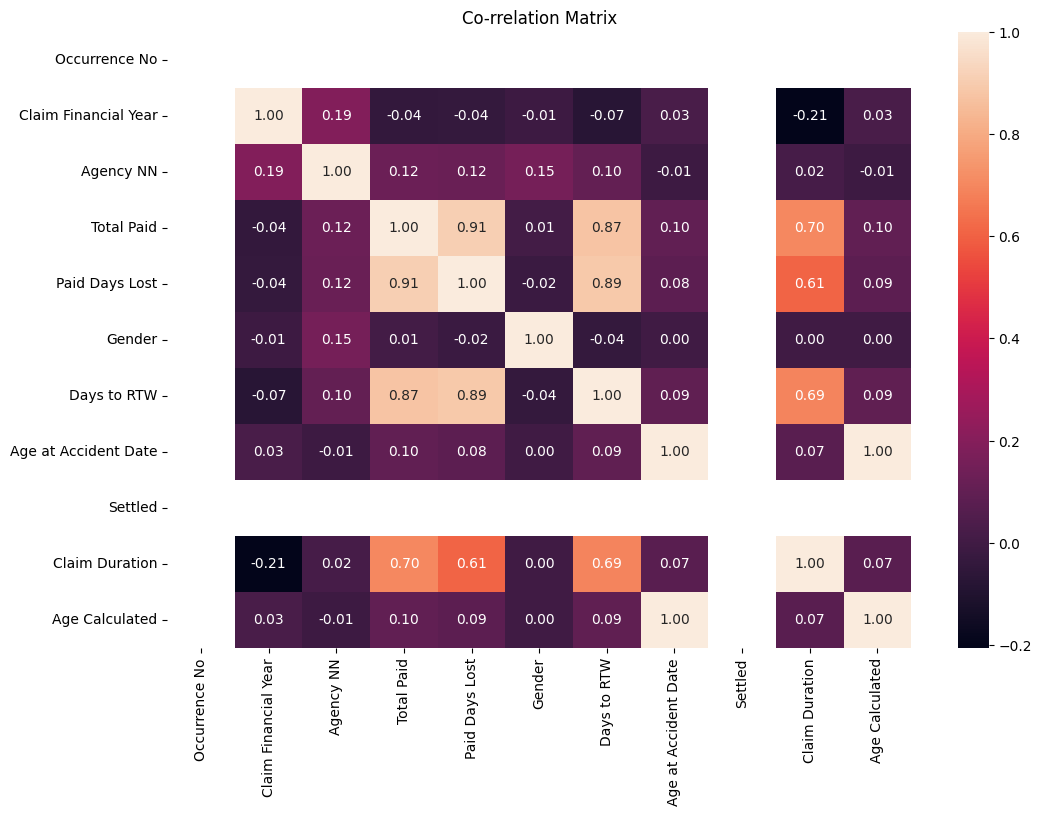

In [132]:

# CO-RELATION MATRIX

plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Co-rrelation Matrix")
plt.show()

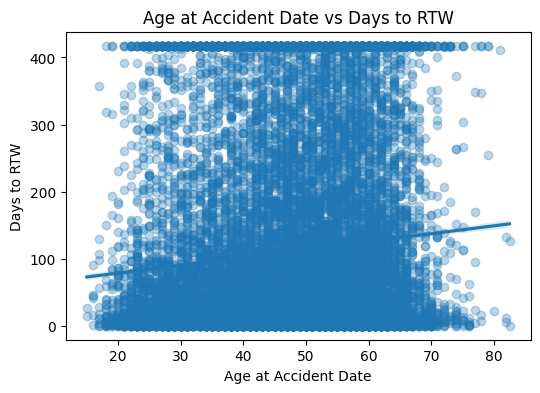

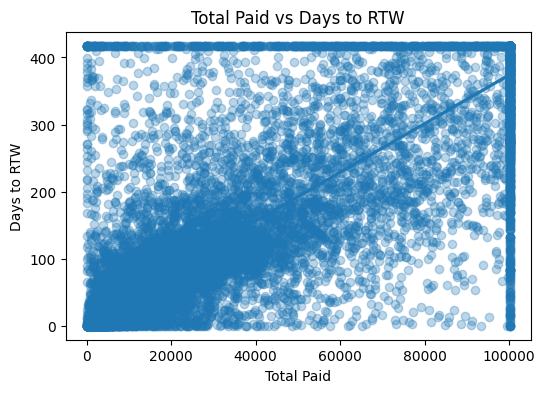

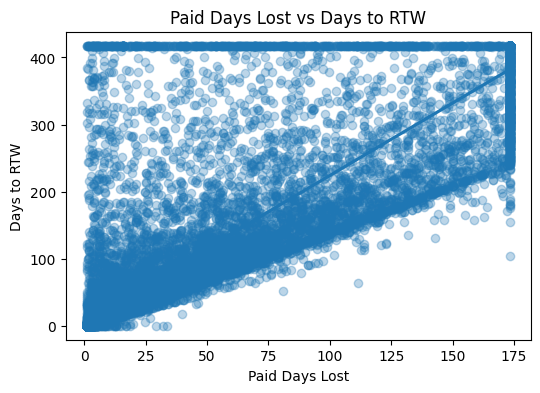

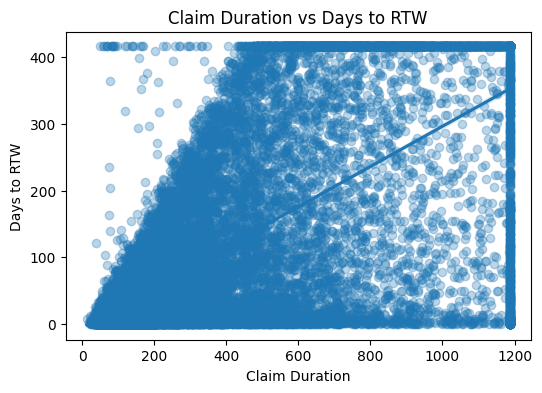

In [133]:

# LINEARITY CHECK 

important_features = [
    "Age at Accident Date",
    "Total Paid",
    "Paid Days Lost",
    "Claim Duration"
]

for col in important_features:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.regplot(x=df[col], y=df[target], scatter_kws={"alpha":0.3})
        plt.title(f"{col} vs {target}")
        plt.show()

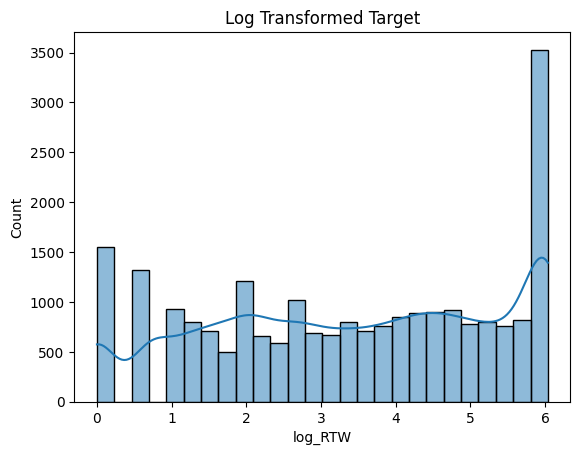

In [134]:

# LOG TRANSFORMATION

df["log_RTW"] = np.log1p(df[target])

plt.figure()
sns.histplot(df["log_RTW"], kde=True)
plt.title("Log Transformed Target")
plt.show()

In [135]:
df["log_RTW"] = np.log1p(df[target])
print(df["log_RTW"].skew())

-0.1851037513738774


The log transformation effectively reduced the skewness of the RTW variable from a highly skewed distribution to near symmetry (skewness = -0.185), indicating improved data balance and suitability for modeling.

In [136]:
from sklearn.model_selection import train_test_split

X = df.drop("RTW Category", axis=1)
y = df["RTW Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [139]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <clas

In [138]:
X_train.select_dtypes(include="object").columns

Index([], dtype='object')